In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

BASE = r"C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge"
DIRS = {
    "sin_procesar":   os.path.join(BASE, "3000imagenes"),
    "eliminar_texto": os.path.join(BASE, "3000imagenes-limpieza-texto"),
    "crop_pulmones":  os.path.join(BASE, "imagenes-crop-8-3000"),
}
df = pd.read_csv(os.path.join(BASE, "df_subset_2994_valido.csv"))

# --- Paso 1: buscar candidatos (uno vertical, uno horizontal) -------------
def dims(rel):
    with Image.open(os.path.join(DIRS["sin_procesar"], str(rel).replace("/", os.sep))) as im:
        return im.size

muestra = df.sample(40, random_state=7)["full_path"].tolist()
cands = []
for rel in muestra:
    try:
        w, h = dims(rel)
        cands.append((rel, w/h))
    except Exception:
        pass

vert = [r for r, a in cands if a < 0.90][:6]
horz = [r for r, a in cands if a > 1.05][:6]
print("Candidatos verticales:", *vert, sep="\n  ")
print("Candidatos horizontales:", *horz, sep="\n  ")

Candidatos verticales:
  files/p15/p15662090/s51535454/6c41e183-436f72b7-0f6b8b25-357356dc-221fbe85.jpg
  files/p17/p17719203/s50165781/e229ec41-4e1e606d-aa2d06f7-e0da9aad-3513737c.jpg
  files/p16/p16545947/s51615376/fc5373ee-869455aa-db9ef41f-0a2b3691-20d82282.jpg
  files/p14/p14675833/s50580468/514ffda8-eb231b0d-0ceba6d7-a3ab90c9-5ca532df.jpg
  files/p16/p16730399/s53466709/a78790a4-a32517cf-1aa755c2-b44c871f-57af15b6.jpg
  files/p10/p10046041/s58110001/de1c0614-2a966eb0-3fa84d6b-85cddea6-b34f75cd.jpg
Candidatos horizontales:
  files/p15/p15080822/s56339275/5b18b9f8-e1d19936-ab8d81de-a53133a2-50cc1370.jpg
  files/p14/p14993854/s50916938/88d3f88f-4042242e-c77c97ae-35104efe-7b1785c5.jpg
  files/p19/p19630262/s58557827/42daaba6-c38156e7-4ac638d5-451f2b0a-f9417786.jpg
  files/p17/p17570754/s58618360/c88b1ed9-d5d94248-8a4959f0-efe39e67-c5427358.jpg
  files/p15/p15378075/s55915235/aa652ebf-e960af43-b0571e24-28e96173-4947ffb4.jpg
  files/p16/p16012048/s54211788/87f273ef-ca409122-c70d761c-20

IndexError: string index out of range

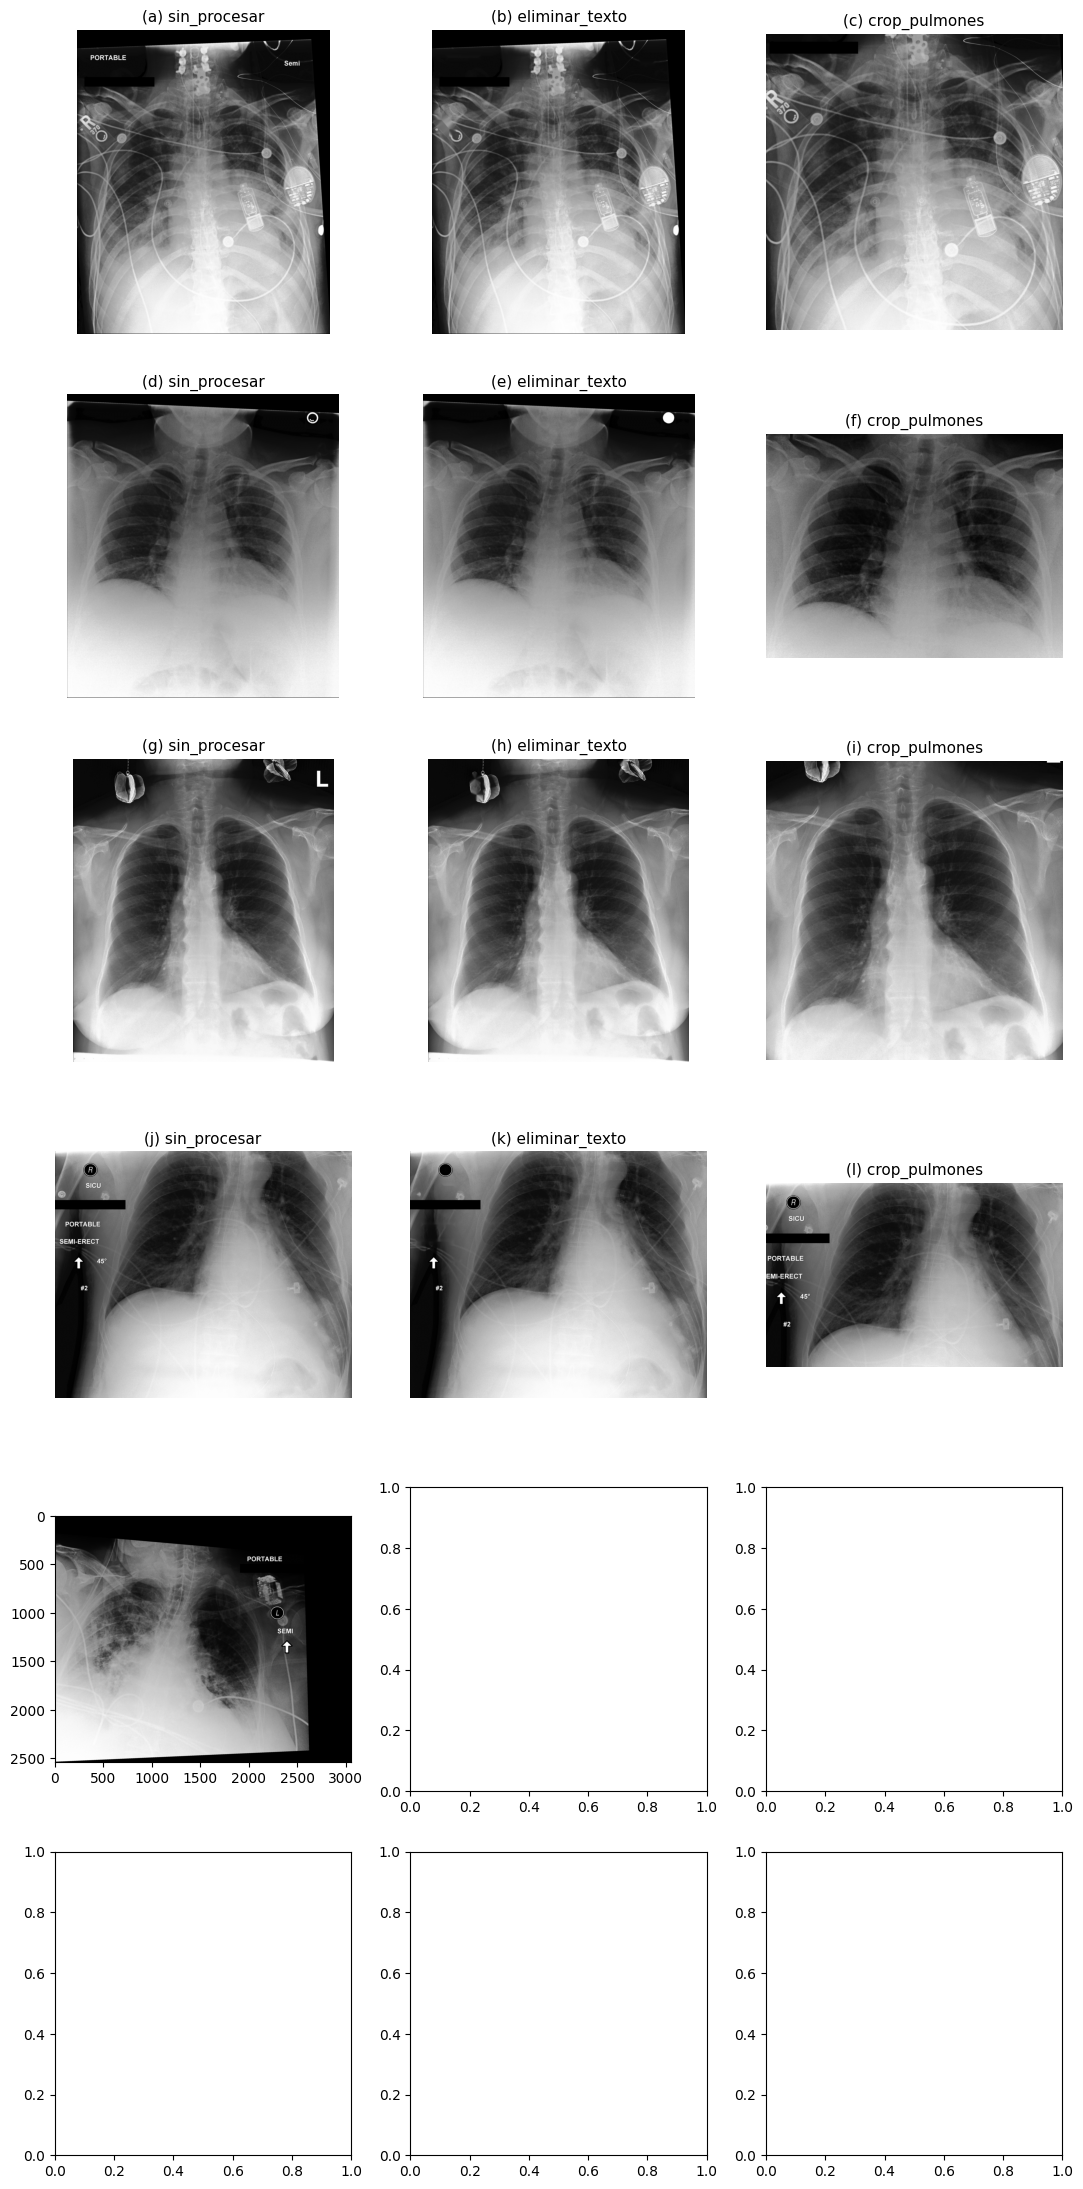

In [8]:
# --- Paso 2: armar la figura ---------------------------------------------
CASOS = [
    "files/p15/p15662090/s51535454/6c41e183-436f72b7-0f6b8b25-357356dc-221fbe85.jpg",
    "files/p17/p17719203/s50165781/e229ec41-4e1e606d-aa2d06f7-e0da9aad-3513737c.jpg",
    "files/p16/p16545947/s51615376/fc5373ee-869455aa-db9ef41f-0a2b3691-20d82282.jpg",
    "files/p19/p19630262/s58557827/42daaba6-c38156e7-4ac638d5-451f2b0a-f9417786.jpg",
    "files/p17/p17570754/s58618360/c88b1ed9-d5d94248-8a4959f0-efe39e67-c5427358.jpg",
    "files/p16/p16012048/s54211788/87f273ef-ca409122-c70d761c-2051e580-07450996.jpg",
]
TITULOS = ["sin_procesar", "eliminar_texto", "crop_pulmones"]
LETRAS = "abcdefghijkl"

fig, axes = plt.subplots(len(CASOS), 3, figsize=(13, 4.6 * len(CASOS)))
axes = axes.reshape(len(CASOS), 3)

k = 0
for i, rel in enumerate(CASOS):
    for j, cond in enumerate(TITULOS):
        ruta = os.path.join(DIRS[cond], str(rel).replace("/", os.sep))
        ax = axes[i, j]
        ax.imshow(Image.open(ruta).convert("L"), cmap="gray")
        ax.set_title(f"({LETRAS[k]}) {cond}", fontsize=11)
        ax.axis("off")
        k += 1

plt.tight_layout()
plt.savefig("figura_condiciones_ejemplos.png", dpi=200, bbox_inches="tight")
plt.show()

Casos seleccionados: 6


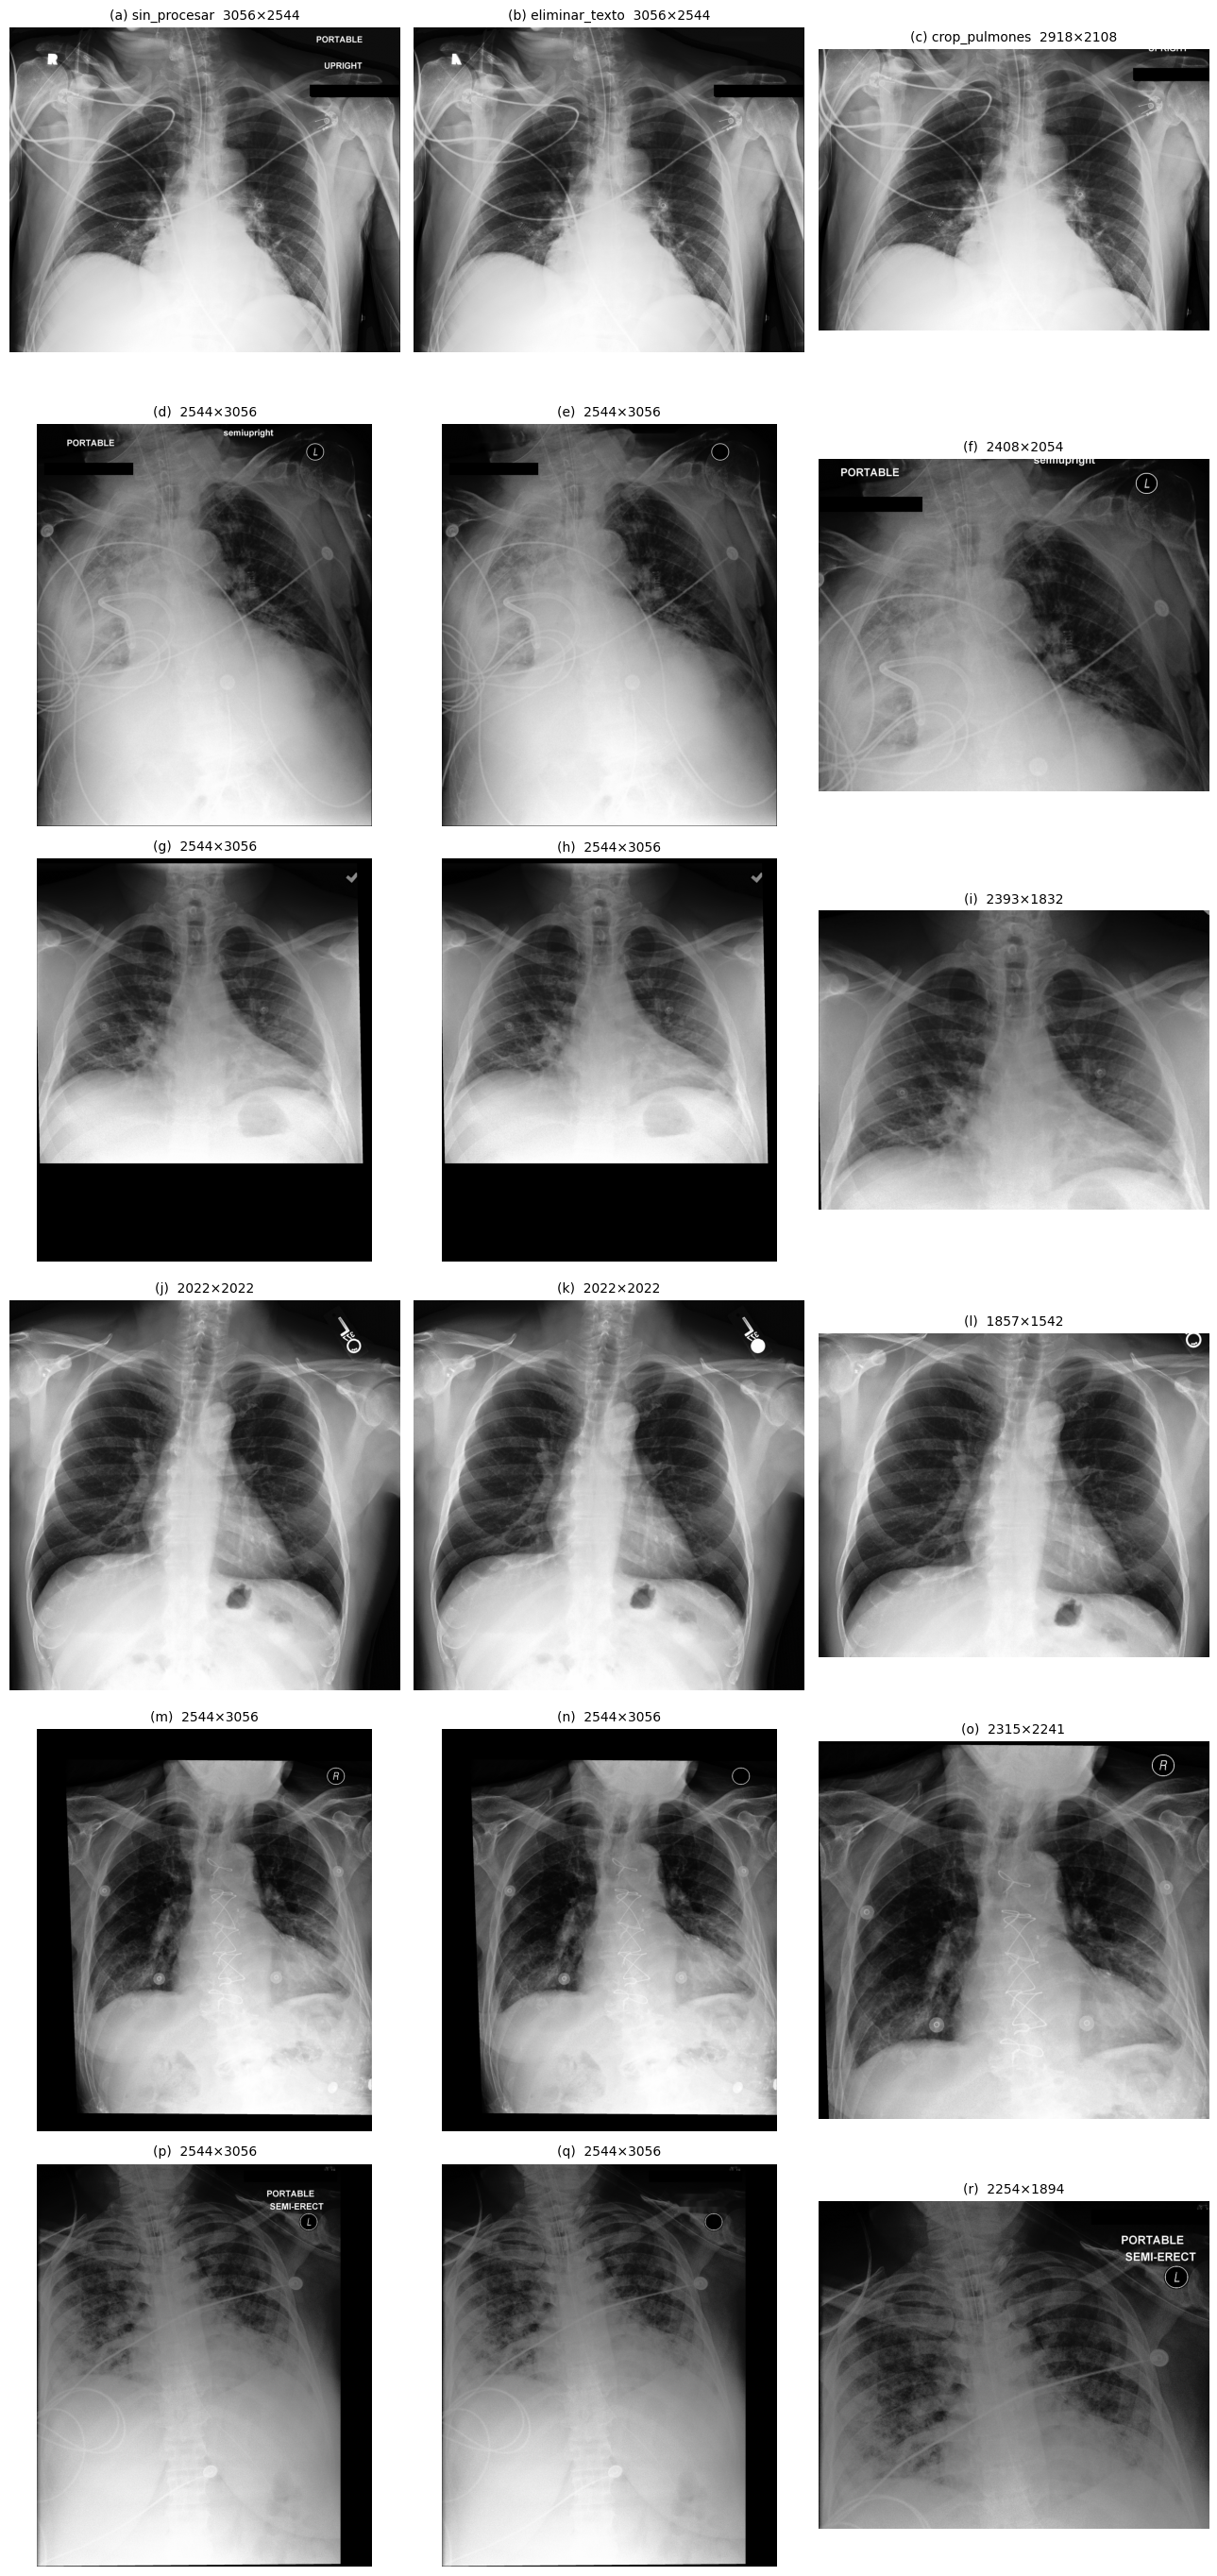

a–c: files/p12/p12199734/s50277315/7d4d52e4-54b07d55-5b3b8438-244df394-2878031a.jpg
d–f: files/p17/p17162389/s50151490/2040ca81-5ebeb3ce-a9365792-40a77cd3-13b459b9.jpg
g–i: files/p18/p18893120/s50059312/929126b2-71c0304d-4ec9b1f2-bcd9bb03-0eaee290.jpg
j–l: files/p17/p17341633/s55402772/75a5fc21-03009776-9f766cbf-5eff9c48-88060a3e.jpg
m–o: files/p17/p17038863/s53968082/c8de8246-b5603bc6-b816af5a-c904fd4e-c8348976.jpg
p–r: files/p13/p13870531/s55582821/cc26c539-8db9b34e-566098dc-1867bcc6-b9562155.jpg


In [11]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

BASE = r"C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge"
DIRS = {
    "sin_procesar":   os.path.join(BASE, "3000imagenes"),
    "eliminar_texto": os.path.join(BASE, "3000imagenes-limpieza-texto"),
    "crop_pulmones":  os.path.join(BASE, "imagenes-crop-8-3000"),
}
TITULOS = list(DIRS.keys())
LETRAS = "abcdefghijklmnopqrstuvwxyz"

N_CASOS = 6      # cuántos estudios mostrar
SEED    = 42     # cambia este número para obtener otro sorteo

df = pd.read_csv(os.path.join(BASE, "df_subset_2994_valido.csv"))

def ruta(cond, rel):
    return os.path.join(DIRS[cond], str(rel).replace("/", os.sep))

def completo(rel):
    return all(os.path.exists(ruta(c, rel)) for c in TITULOS)

random.seed(SEED)
pool = df["full_path"].tolist()
random.shuffle(pool)
casos = [r for r in pool if completo(r)][:N_CASOS]
print(f"Casos seleccionados: {len(casos)}")

fig, axes = plt.subplots(len(casos), 3, figsize=(13, 4.6 * len(casos)))
axes = axes.reshape(len(casos), 3)

k = 0
for i, rel in enumerate(casos):
    for j, cond in enumerate(TITULOS):
        with Image.open(ruta(cond, rel)) as im:
            w, h = im.size
            axes[i, j].imshow(im.convert("L"), cmap="gray")
        etiqueta = f"({LETRAS[k]}) {cond}" if i == 0 else f"({LETRAS[k]})"
        axes[i, j].set_title(f"{etiqueta}  {w}×{h}", fontsize=10)
        axes[i, j].axis("off")
        k += 1

plt.tight_layout()
plt.savefig(f"condiciones_seed{SEED}.png", dpi=180, bbox_inches="tight")
plt.show()

for i, rel in enumerate(casos):
    print(f"{LETRAS[i*3]}–{LETRAS[i*3+2]}: {rel}")

In [12]:
import os, pandas as pd
from PIL import Image

BASE = r"C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge"
ORIG = os.path.join(BASE, "3000imagenes")
CROP = os.path.join(BASE, "imagenes-crop-8-3000")
df = pd.read_csv(os.path.join(BASE, "df_subset_2994_valido.csv"))

filas = []
for rel in df["full_path"]:
    r = str(rel).replace("/", os.sep)
    try:
        with Image.open(os.path.join(ORIG, r)) as a, Image.open(os.path.join(CROP, r)) as b:
            wo, ho = a.size; wc, hc = b.size
        filas.append({"area_ret": (wc*hc)/(wo*ho), "aspecto": wo/ho})
    except Exception:
        pass

d = pd.DataFrame(filas)
d["reduccion_%"] = (1 - d["area_ret"]) * 100
print(d["reduccion_%"].describe().round(2))
print("\nPor orientación:")
d["orient"] = pd.cut(d["aspecto"], [0, .95, 1.05, 9], labels=["vertical","cuadrada","horizontal"])
print(d.groupby("orient", observed=True)["reduccion_%"].agg(["count","mean","min","max"]).round(2))

count    2990.00
mean       28.42
std        14.18
min         0.00
25%        18.10
50%        28.03
75%        37.76
max        99.98
Name: reduccion_%, dtype: float64

Por orientación:
            count   mean   min    max
orient                               
vertical     1752  28.64  0.00  98.27
cuadrada      224  33.98  5.12  97.42
horizontal   1014  26.79  0.00  99.98


In [13]:
faltan = [r for r in df["full_path"]
          if not os.path.exists(os.path.join(CROP, str(r).replace("/", os.sep)))]
print("Rutas del CSV sin archivo en crop:", len(faltan))
for r in faltan: print("  ", r)

d2 = d.copy()
print("\nRecortes extremos:")
print("  >80% de área eliminada:", (d2["reduccion_%"] > 80).sum())
print("  >60%:", (d2["reduccion_%"] > 60).sum())
print("  <1% (recorte nulo):", (d2["reduccion_%"] < 1).sum())

Rutas del CSV sin archivo en crop: 4
   files/p16/p16019229/s55664504/f38bc970-8c6ba682-c2b93a26-9999954e-c6746579.jpg
   files/p13/p13421580/s55749095/b5cd5972-6de1d0a8-65f54917-02fd239c-37171ea6.jpg
   files/p11/p11226173/s51015329/7d0e538c-e4990205-2f288b22-36ed75ba-d2e7f917.jpg
   files/p17/p17980556/s56036487/b8f1ba56-b32c6c6b-9f6079bd-f56acefc-77dd0a86.jpg

Recortes extremos:
  >80% de área eliminada: 5
  >60%: 52
  <1% (recorte nulo): 31


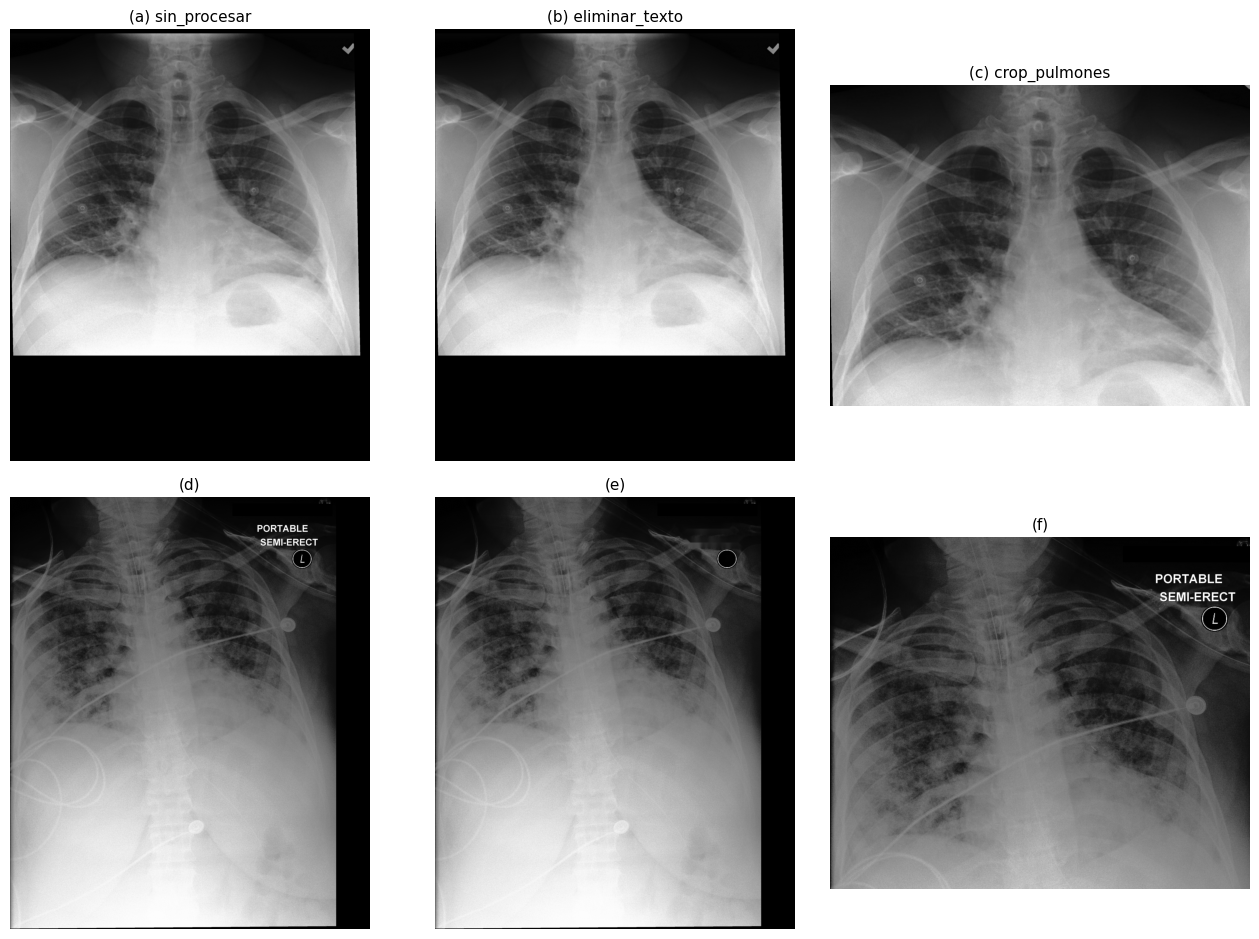

In [14]:
import os
import matplotlib.pyplot as plt
from PIL import Image

BASE = r"C:\Users\trodr\Documents\proyecto-torax-v2.0\01-dataset\dataset-completo-merge"
DIRS = {
    "sin_procesar":   os.path.join(BASE, "3000imagenes"),
    "eliminar_texto": os.path.join(BASE, "3000imagenes-limpieza-texto"),
    "crop_pulmones":  os.path.join(BASE, "imagenes-crop-8-3000"),
}
TITULOS = list(DIRS.keys())
LETRAS = "abcdef"

CASOS = [
    "files/p18/p18893120/s50059312/929126b2-71c0304d-4ec9b1f2-bcd9bb03-0eaee290.jpg",
    "files/p13/p13870531/s55582821/cc26c539-8db9b34e-566098dc-1867bcc6-b9562155.jpg",
]

fig, axes = plt.subplots(2, 3, figsize=(13, 9.5))
k = 0
for i, rel in enumerate(CASOS):
    for j, cond in enumerate(TITULOS):
        ruta = os.path.join(DIRS[cond], rel.replace("/", os.sep))
        axes[i, j].imshow(Image.open(ruta).convert("L"), cmap="gray")
        titulo = f"({LETRAS[k]}) {cond}" if i == 0 else f"({LETRAS[k]})"
        axes[i, j].set_title(titulo, fontsize=11)
        axes[i, j].axis("off")
        k += 1

plt.tight_layout()
plt.savefig("figura6_comparativa_condiciones.png", dpi=220, bbox_inches="tight")
plt.show()